```{index} Support settlement; Class exercise
```
```{index} Stiffness influences; Class exercise
```


(lesson8.2)=
# Lesson October 23th

During today's lesson you'll work on a complex exercise on the topic of Stiffness discontinuities and Support settlement. Please ask your questions regarding the [homework](homework8.2) as well!

## Exercise Support settlement

Given the following structure.

```{figure} intro_data/structure.svg
:align: center
```

1. Find the moment distribution for $n=1$


````{admonition} Solution assignment 1
:class: tip, dropdown

```{figure} intro_data/M-line.svg
:align: center
```

````

## Exercise Stiffness discontinuities

2. Find the moment distribution for $n=0$
3. Find the moment distribution for $n \to \infty$
4. Find the moment om $\rm{B}$ and $\rm{C}$ for an arbitrary value for $n$

````{admonition} Solution assignment 2
:class: tip, dropdown

```{figure} intro_data/M-line-2.svg
:align: center
```

````

````{admonition} Solution assignment 3
:class: tip, dropdown

```{figure} intro_data/M-line-3.svg
:align: center
```
````

````{admonition} Solution assignment 4
:class: tip, dropdown

- $M_{\rm{B}} = \cfrac{75n}{42+2}$
- $M_{\rm{C}} = \cfrac{75n}{42+2}$

```{figure} intro_data/steunpuntszetting.svg
:align: center
```

````

In [1]:
import sympy as sym

EI = sym.nsimplify(25e3)
w = sym.nsimplify(0.025)

M_B, M_C = sym.symbols('M_B M_C')

eq1 = sym.Eq(-M_B * 10 / 3 / EI + w / 10 ,0)
M_B_1 = sym.solve(eq1, M_B)[0]

eq2 = sym.Eq(M_B * 10 / 3 / EI - w / 10, w / 10)
eq3 = sym.Eq(w/10, M_C * 10 / 3 / EI)
M_B_2 = sym.solve(eq2, M_B)[0]
M_C_2 = sym.solve(eq3, M_C)[0]

display(M_B_1, M_B_2, M_C_2)
display(M_B_1 - M_B_2, M_C_2)

75/4

75/2

75/4

-75/4

75/4

In [17]:
M_B, M_C = sym.symbols('M_B M_C')
n = sym.symbols('n', positive=True)

phi_B_AB = M_B * 10 / EI / 3
phi_B_BC = - M_B * 10 / EI / 3 / n + w / 10 - M_C * 10 / EI / 6 / n 
phi_C_BC = M_C * 10 / EI / 3 / n + w / 10 + M_B * 10 / EI / 6 / n
phi_C_CD = - M_C * 10 / EI / 3

eq1 = sym.Eq(phi_B_AB, phi_B_BC)
eq2 = sym.Eq(phi_C_CD, phi_C_BC)

sol = sym.solve((eq1, eq2), (M_B, M_C))
display(sol[M_B], sol[M_C])
display(sol[M_B].evalf(), sol[M_C].evalf())

75*n/(4*n + 2)

-75*n/(4*n + 2)

75.0*n/(4.0*n + 2.0)

-75.0*n/(4.0*n + 2.0)

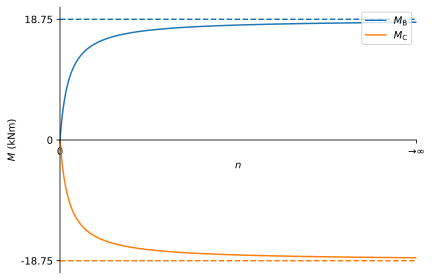

In [18]:
import numpy as np
%config InlineBackend.figure_formats = ['svg']
n_max = 20
n_eval = np.linspace(0, n_max, 1000)
M_B = sym.lambdify(n, sol[M_B])
M_C = sym.lambdify(n, sol[M_C])

import matplotlib.pyplot as plt
plt.plot(n_eval, M_B(n_eval), label=r'$M_{\rm{B}}$')
# get color of last line
line = plt.gca().lines[-1]
color = line.get_color()
plt.plot([0, n_max], [18.75,18.75], '--',color=color)

plt.plot(n_eval, M_C(n_eval), label=r'$M_{\rm{C}}$')
line = plt.gca().lines[-1]
color = line.get_color()
plt.plot([0, n_max], [-18.75,-18.75], '--',color=color)
plt.xlim([0,n_max])
plt.xlabel('$n$')
plt.ylabel(r'$M \ \rm{(kNm)}$')
ax = plt.gca()
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')
# add yticks at 3/16 and -3/16+1/4
plt.yticks([-18.75,0,18.75],('-18.75','0','18.75'))
plt.xticks([0, n_max], ['0', '$ →  \infty$'])
plt.legend(loc='upper right');

#plt.gcf().patch.set_alpha(0)
#ax.set_facecolor('none')
#plt.savefig('steunpuntszetting.svg', transparent=True, bbox_inches='tight')